# Dev info
- Feature: Use Numpy interpolation to fill the gaps
- Runs on: ReSurfEMG V1.1.1
- Methods: resurfemg.preprocessing.ecg_removal.gating

- Explanation: Gating method used a custom implementation for interpolation to
fill the gate windows. Using dedicated Numpy methods might speed-up to process
and make the function more transparent.

# 1. Import the required libraries

In [ ]:
# Standard code libraries
import copy
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy

import resurfemg.preprocessing.filtering as filt
from resurfemg.data_connector import file_discovery

# Custom code libraries from ReSurfEMG
from resurfemg.data_connector.config import Config
from resurfemg.data_connector.converter_functions import load_file
from resurfemg.pipelines import ipy_widgets
from resurfemg.preprocessing import envelope as evl
from resurfemg.preprocessing.ecg_removal import detect_ecg_peaks

config = Config()

%matplotlib widget

INFO:resurfemg.data_connector.config:Loaded config from: config.json


## 2. Load sEMG test data

## Synthetic data

In [45]:
# For the test data:
base_path = config.get_directory('test_data')

files = file_discovery.find_files(
    base_path=base_path,
    file_name_regex='*',
    extension_regex='Poly5',
    folder_levels=None,
    verbose=False
)
button_list = ipy_widgets.file_select(
    files=files,
    folder_levels=['files'],
    default_value_select=None,
    default_idx_select=[0])

interactive(children=(Dropdown(description='files:', options=('emg_data_synth_pocc.Poly5', 'emg_data_synth_qui…

## Patient data

In [32]:
# # Identify all recordings available for the selected patient/measurement_date

# # First find the patients
# config = Config()
# base_path = config.get_directory('root_patient_data')
# patient_paths = file_discovery.find_folders(
#     base_path,
#     folder_levels=['patient'])
# patient = list(patient_paths['patient'].values)[0]

# # Then find the files for the selected patients:
# folder_levels = ['date', 'measurement']
# patient_path = os.path.join(base_path, patient)

# emg_files = file_discovery.find_files(
#     base_path=patient_path,
#     file_name_regex='EMG_recording',
#     extension_regex='poly5',
#     folder_levels=folder_levels)

# folder_levels = ['date', 'measurement']
# vent_files = file_discovery.find_files(
#     base_path=patient_path,
#     file_name_regex='Draeger_recording',
#     extension_regex='poly5',
#     folder_levels=folder_levels)

# button_list = ipy_widgets.file_select(
#     emg_files,
#     folder_levels=folder_levels,
#     default_value_select=None,
#     default_idx_select=[1, 6, None])
# emg_file_chosen = os.path.join(
#     patient_path, *[btn.value for btn in button_list], 'EMG_recording.Poly5')
# vent_file_chosen = os.path.join(
#     patient_path, *[btn.value for btn in button_list], 'Draeger_recording.Poly5')

# print("The chosen files are:\n", emg_file_chosen, '\n', vent_file_chosen)

In [33]:
# Load the EMG from the selected folders (synthetic data):
emg_file_chosen = os.path.join(base_path, *[btn.value for btn in button_list])

# # Load the EMG from the selected folders:
# emg_file_chosen = os.path.join(patient_path, *[btn.value for btn in button_list])

y_emg_raw, _, metadata_emg = load_file(emg_file_chosen)
fs_emg = metadata_emg['fs']

t_emg = [i/fs_emg for i in range(len(y_emg_raw[0, :]))]

# Load the Ventilator from the selected folders:
# y_vent, _, metadata_vent = load_file(vent_file_chosen)
# fs_vent = metadata_vent['fs']
# 
# y_vent = y_vent
# t_vent = [i/fs_vent for i in range(len(y_vent[0, :]))]


INFO:resurfemg.data_connector.converter_functions:Detected .poly5
INFO:resurfemg.data_connector.converter_functions:Loading .Poly5 ...
INFO:resurfemg.data_connector.tmsisdk_lite:Reading file C:\Users\ManinettiC\OneDrive - University of Twente\Documents\ReSurfEMG\test_data\emg_data_synth_quiet_breathing.Poly5
INFO:resurfemg.data_connector.tmsisdk_lite:	 Number of samples:  860160 
INFO:resurfemg.data_connector.tmsisdk_lite:	 Number of channels:  2 
INFO:resurfemg.data_connector.tmsisdk_lite:	 Sample rate: 2048 Hz
INFO:resurfemg.data_connector.tmsisdk_lite:Done reading data.
INFO:resurfemg.data_connector.converter_functions:Loaded .Poly5, extracting data ...
INFO:resurfemg.data_connector.converter_functions:Loading data completed
INFO:resurfemg.data_connector.converter_functions:Selected channels: [0, 1]


# 3. Pre-process the data

In [34]:
# Gating for comparison
y_emg_filt = filt.emg_bandpass_butter(
    y_emg_raw,
    fs_emg=fs_emg,
    high_pass=20,
    low_pass=500,
    order=4,
)


In [35]:
# Detect ECG peaks
ecg_peaks_idxs = detect_ecg_peaks(
    ecg_raw=y_emg_raw[0, :],
    fs=fs_emg)

# 4. Define the original implementation of the code and the vectorized version

In [ ]:
import resurfemg.preprocessing.filtering as filt

# Gate fill method constants (avoid magic-number comparisons)
# 0: filled with zeros, 1: interpolation, 2: prior-window mean, 3: RMS running average
_GATE_FILL_ZEROS = 0
_GATE_FILL_INTERP = 1
_GATE_FILL_PRIOR_MEAN = 2
_GATE_FILL_RMS = 3
_GATE_FILL_QUADRATIC = 4


def detect_ecg_peaks(
    ecg_raw: np.ndarray,
    fs: int,
    peak_fraction: float = 0.4,
    peak_width_s: int | None = None,
    peak_distance: int | None = None,
    bp_filter: bool = True,
) -> np.ndarray:
    """Detect ECG peaks in EMG signal.

    Args:
        ecg_raw (numpy.ndarray): ECG signals to detect the ECG peaks in.
        fs (int): Sampling rate of the EMG signals.
        peak_fraction (float): ECG peaks amplitude threshold relative to the
            specified fraction of the min-max values in the ECG signal.
        peak_width_s (int, optional): ECG peaks width threshold in samples.
        peak_distance (int, optional): Minimum time between ECG peaks in samples.
        bp_filter (bool): Bandpass filter the ecg_raw between 1-500 Hz before
            peak detection.

    Returns:
        numpy.ndarray: ECG peak indices.
    """
    if peak_width_s is None:
        peak_width_s = fs // 1000

    if peak_distance is None:
        peak_distance = fs // 3

    if bp_filter:
        lp_cf = min([500, 0.95 * fs / 2])
        ecg_filt = filt.emg_bandpass_butter(ecg_raw, high_pass=1, low_pass=lp_cf, fs_emg=fs)
        ecg_rms = evl.full_rolling_rms(ecg_filt, fs // 200)
    else:
        ecg_rms = evl.full_rolling_rms(ecg_raw, fs // 200)
    max_ecg_rms = np.percentile(ecg_rms, 99)
    min_ecg_rms = np.percentile(ecg_rms, 1)
    peak_height = peak_fraction * (max_ecg_rms - min_ecg_rms)

    ecg_peak_idxs, _ = scipy.signal.find_peaks(ecg_rms, height=peak_height, width=peak_width_s, distance=peak_distance)

    return ecg_peak_idxs


def _windowed_masked_mean(source: np.ndarray, starts: np.ndarray, width: int, max_sample: int) -> np.ndarray:
    """Windowed masked mean.

    Mean over [start, start + width) windows of `source`, ignoring both
    out-of-bounds positions and NaN values via a MaskedArray. Fully-empty
    windows return NaN.

    Args:
        source (numpy.ndarray): 1D array to window over.
        starts (numpy.ndarray): Window start index per row.
        width (int): Window length.
        max_sample (int): Length of source (out-of-bounds bound).

    Returns:
        numpy.ndarray: Per-window mean, NaN where the window is fully masked.
    """
    idx = starts[:, None] + np.arange(width)  # (K, width)
    oob = (idx < 0) | (idx >= max_sample)
    vals = source[np.clip(idx, 0, max_sample - 1)]
    masked = np.ma.array(vals, mask=oob | np.isnan(vals))
    return masked.mean(axis=1).filled(np.nan)  # (K,)


def _get_emg_raw_gated_rms(emg_raw_gated: np.ndarray, gate_mask: np.ndarray, gate_width: int) -> np.ndarray:
    # define this helper for reusability as it's used in both RMS and quadratic methods
    emg_raw_gated_base = copy.deepcopy(emg_raw_gated)
    emg_raw_gated_base[gate_mask] = np.nan
    return evl.full_rolling_rms(emg_raw_gated_base, gate_width)


def _gate_fill_interp(
    k_start: np.ndarray,
    emg_raw_gated: np.ndarray,
    gated_idx: np.ndarray,
    peaks: np.ndarray,
    half_gate_width: int,
    gate_width: int,
    max_sample: int,
) -> np.ndarray:
    if gated_idx.size == 0:
        return emg_raw_gated

    pre_idx = peaks - half_gate_width - 1
    post_idx = peaks + half_gate_width + 1
    pre_in = (pre_idx >= 0) & (pre_idx < max_sample)
    post_in = (post_idx >= 0) & (post_idx < max_sample)
    pre_val = np.where(pre_in, emg_raw_gated[np.clip(pre_idx, 0, max_sample - 1)], 0.0)
    post_val = np.where(post_in, emg_raw_gated[np.clip(post_idx, 0, max_sample - 1)], 0.0)

    owner = np.clip(np.searchsorted(k_start, gated_idx, side="right") - 1, 0, len(peaks) - 1)
    frac = (gated_idx - peaks[owner] + half_gate_width) / float(gate_width)
    emg_raw_gated[gated_idx] = (1.0 - frac) * pre_val[owner] + frac * post_val[owner]
    return emg_raw_gated


def _gate_fill_prior_mean(
    emg_raw: np.ndarray,
    emg_raw_gated: np.ndarray,
    gated_idx: np.ndarray,
    k_start: np.ndarray,
    peaks: np.ndarray,
    half_gate_width: int,
    gate_width: int,
    max_sample: int,
) -> np.ndarray:
    prior_start = peaks - half_gate_width * 3
    clamped = prior_start < 0
    prior_means = _windowed_masked_mean(emg_raw, prior_start, gate_width, max_sample)
    post_means = _windowed_masked_mean(emg_raw, peaks + half_gate_width, gate_width, max_sample)
    fill_means = np.where(clamped, post_means, prior_means)

    owner = np.clip(np.searchsorted(k_start, gated_idx, side="right") - 1, 0, len(peaks) - 1)
    emg_raw_gated[gated_idx] = fill_means[owner]
    return emg_raw_gated


def _gate_fill_rms(
    emg_raw_gated: np.ndarray,
    gate_mask: np.ndarray,
    gated_idx: np.ndarray,
    gate_width: int,
    max_sample: int,
) -> np.ndarray:
    emg_raw_gated_rms = _get_emg_raw_gated_rms(emg_raw_gated, gate_mask, gate_width)

    w = max(1, 2 * int(1.5 * gate_width) + 1)
    closed = "neither" if gate_width % 2 == 0 else "left"
    local_mean = pd.Series(emg_raw_gated_rms).rolling(window=w, min_periods=1, center=True, closed=closed).mean().values

    fill_vals = np.asarray(local_mean[gated_idx])
    interp_mask = np.isnan(fill_vals)
    emg_raw_gated[gated_idx[~interp_mask]] = fill_vals[~interp_mask]

    return _interp_missing_samples(emg_raw_gated, interp_mask, gated_idx, max_sample)


def _interp_missing_samples(
    emg_raw_gated: np.ndarray,
    interp_mask: np.ndarray,
    sample_idxs: np.ndarray,
    max_sample: int,
) -> np.ndarray:
    interpolate_samples = sample_idxs[interp_mask]
    if interpolate_samples.size == 0:
        return emg_raw_gated

    # Boundary handling: pin a gated endpoint to 0 and PROMOTE it to an anchor
    # (drop it from the interpolation targets) so interior samples ramp from 0,
    # instead of being overwritten and flat-clamped to the first interior value.
    if interpolate_samples[0] == 0:
        emg_raw_gated[0] = 0.0
        interpolate_samples = interpolate_samples[1:]
    if interpolate_samples.size and interpolate_samples[-1] == max_sample - 1:
        emg_raw_gated[-1] = 0.0
        interpolate_samples = interpolate_samples[:-1]
    if interpolate_samples.size == 0:
        return emg_raw_gated

    x_samp = np.arange(max_sample)
    other_mask = ~np.isin(x_samp, interpolate_samples)
    if not other_mask.any():  # no anchors left to interpolate from
        return emg_raw_gated

    emg_raw_gated[interpolate_samples] = np.interp(interpolate_samples, x_samp[other_mask], emg_raw_gated[other_mask])
    return emg_raw_gated


def _gate_fill_quadratic(
    emg_raw_gated: np.ndarray,
    gate_mask: np.ndarray,
    gated_idx: np.ndarray,
    gate_width: int,
    max_sample: int,
    poly_width: int = 5 * 205,
) -> np.ndarray:
    emg_raw_gated_rms = _get_emg_raw_gated_rms(emg_raw_gated, gate_mask, gate_width)
    emg_raw_gated_rms[gate_mask] = np.nan
    # Seed the gate region to NaN so that segments the fit can't cover remain
    # NaN and get caught by the interp fallback below. Support is read from the
    # RMS array, not from emg_raw_gated, so blanking the signal here is safe.
    emg_raw_gated[gate_mask] = np.nan
    # vectorizing this block actually slows the code down, so we keep it as a loop over segments
    if gated_idx.size > 0:
        breaks = np.diff(gated_idx) != 1
        seg_starts = gated_idx[np.concatenate(([True], breaks))]
        seg_ends = gated_idx[np.concatenate((breaks, [True]))]
        for gs, ge in zip(seg_starts, seg_ends, strict=False):
            pre_s = max(0, gs - poly_width // 2)
            post_e = min(max_sample, ge + 1 + poly_width // 2)

            # support indices and values from RMS (skip NaNs)
            idx_pre = np.arange(pre_s, gs)
            idx_post = np.arange(ge + 1, post_e)
            support_idx = np.concatenate((idx_pre, idx_post))
            support_vals = emg_raw_gated_rms[support_idx]
            valid_mask = ~np.isnan(support_vals)
            valid_idx = support_idx[valid_mask]
            valid_vals = support_vals[valid_mask]

            # fit polynomial to valid RMS support
            fit_available = valid_idx.size >= 2  # noqa: PLR2004
            if fit_available:
                deg = min(2, valid_idx.size - 1)
                p_seg = np.polyfit(valid_idx - gs, valid_vals, deg)  # center x on gs
                ks = np.arange(gs, ge + 1)
                emg_raw_gated[gs : ge + 1] = np.polyval(p_seg, ks - gs)  # evaluate on same offset
    interp_mask = np.isnan(emg_raw_gated[gated_idx])
    # now interpolate any remaining NaN samples
    return _interp_missing_samples(emg_raw_gated, interp_mask, gated_idx, max_sample)


def gating_vectorized(
    emg_raw: np.ndarray, peak_idxs: list | np.ndarray, gate_width: int = 205, method: int = 3, **kwargs
) -> np.ndarray:
    """Gating removal of QRS complexes.

    Eliminate peaks (e.g. QRS) from emg_raw using gates
    of width gate_width. The gate either filled by zeros or interpolation.
    The filling method for the gate is encoded as follows:
    0: Filled with zeros
    1: Interpolation samples before and after
    2: Fill with average of prior segment if exists
    otherwise fill with post segment
    3: Fill with running average of RMS (default)

    Args:
        emg_raw (numpy.ndarray): Signal to process.
        peak_idxs (list or numpy.ndarray): List of individual peak index places to
            be gated.
        gate_width (int): Width of the gate.
        method (int): Filling method of gate.
        **kwargs: Additional keyword arguments for interpolation.

    Returns:
        numpy.ndarray: The gated result.
    """
    # all methods require the gate mask, so we can compute it here to avoid rewriting the same logic in each method
    peaks = np.sort(np.asarray(peak_idxs))
    emg_raw_gated = copy.deepcopy(emg_raw)
    max_sample = emg_raw_gated.shape[0]
    # the half_gate_width is computed via integer division for methods 0, 1, and 2,
    # but via float division for methods 3 and 4. The rest of the mask computation is identical for all methods.
    half_gate_width = gate_width / 2 if method in (_GATE_FILL_RMS, _GATE_FILL_QUADRATIC) else gate_width // 2
    k_start = np.clip(peaks - half_gate_width, 0, max_sample).astype(int)
    k_end = np.clip(peaks + half_gate_width, 0, max_sample).astype(int)
    delta = np.zeros(max_sample + 1, dtype=np.int64)
    np.add.at(delta, k_start, 1)  # +1 entering each gate
    np.add.at(delta, k_end, -1)  # -1 leaving each gate
    gate_mask = np.cumsum(delta)[:max_sample] > 0

    # Each method gets its own helper function to improve code readability and reduce the complexity of the main gating function.
    if method == _GATE_FILL_ZEROS:  # 0
        emg_raw_gated[gate_mask] = 0
        return emg_raw_gated

    # again, this is a common step for all non-zero methods, so we can compute it once here.
    gated_idx = np.nonzero(gate_mask)[0]

    if method == _GATE_FILL_INTERP:  # 1
        emg_raw_gated = _gate_fill_interp(
            k_start,
            emg_raw_gated,
            gated_idx,
            peaks,
            int(half_gate_width),
            gate_width,
            max_sample,
        )
    elif method == _GATE_FILL_PRIOR_MEAN:  # 2
        emg_raw_gated = _gate_fill_prior_mean(
            emg_raw,
            emg_raw_gated,
            gated_idx,
            k_start,
            peaks,
            int(half_gate_width),
            gate_width,
            max_sample,
        )
    elif method == _GATE_FILL_RMS:  # 3
        emg_raw_gated = _gate_fill_rms(emg_raw_gated, gate_mask, gated_idx, gate_width, max_sample)
    elif method == _GATE_FILL_QUADRATIC:  # 4
        poly_width = kwargs.get("poly_width", 5 * gate_width)
        emg_raw_gated = _gate_fill_quadratic(emg_raw_gated, gate_mask, gated_idx, gate_width, max_sample, poly_width)
    else:
        msg = f"Invalid method {method}."
        raise ValueError(msg)

    return emg_raw_gated


def gating_original(emg_raw, peak_idxs, gate_width=205, method=1, **kwargs):  # noqa: ANN001, ANN201, C901, PLR0912, PLR0915
    """Eliminate peaks (e.g. QRS) from emg_raw using gates
    of width gate_width. The gate either filled by zeros or interpolation.
    The filling method for the gate is encoded as follows:
    0: Filled with zeros
    1: Interpolation samples before and after
    2: Fill with average of prior segment if exists
    otherwise fill with post segment
    3: Fill with running average of RMS (default).
    ---------------------------------------------------------------------------
    :param emg_raw: Signal to process
    :type emg_raw: ~numpy.ndarray
    :param peak_idxs: list of individual peak index places to be gated
    :type peak_idxs: ~list
    :param gate_width: width of the gate
    :type gate_width: int
    :param method: filling method of gate
    :type method: int

    :returns emg_raw_gated: the gated result
    :rtype emg_raw_gated: numpy.ndarray
    """  # noqa: D205
    emg_raw_gated = copy.deepcopy(emg_raw)
    max_sample = emg_raw_gated.shape[0]
    half_gate_width = gate_width // 2
    if method == 0:
        # Method 0: Fill with zeros
        # Vectorized construction of gate sample indices
        peaks = np.asarray(peak_idxs, dtype=int).ravel()
        if peaks.size == 0:
            gate_samples = np.array([], dtype=int)
        else:
            starts = np.maximum(0, peaks - half_gate_width)
            ends = np.minimum(max_sample, peaks + half_gate_width)
            # build ranges per peak and concat, then unique to avoid duplicates
            gate_samples = np.concatenate([np.arange(s, e) for s, e in zip(starts, ends)])  # noqa: B905
            gate_samples = np.unique(gate_samples).astype(int)

        emg_raw_gated[gate_samples] = 0
    elif method == 1:
        # Method 1: Fill with interpolation pre- and post gate sample
        peaks = np.asarray(peak_idxs, dtype=int).ravel()
        if peaks.size > 0:
            max_sample = emg_raw_gated.shape[0]
            for peak in peaks:
                pre_idx = peak - half_gate_width - 1
                pre_val = emg_raw[pre_idx] if (pre_idx >= 0 and pre_idx < max_sample) else 0

                post_idx = peak + half_gate_width + 1
                post_val = emg_raw[post_idx] if (post_idx >= 0 and post_idx < max_sample) else 0

                k_start = max(0, peak - half_gate_width)
                k_end = min(peak + half_gate_width, max_sample)
                if k_start >= k_end:
                    continue

                ks = np.arange(k_start, k_end)
                frac = (ks - peak + half_gate_width) / float(gate_width)
                emg_raw_gated[ks] = (1.0 - frac) * pre_val + frac * post_val

    elif method == 2:  # noqa: PLR2004
        # Method 2: Fill with window length mean over prior section
        # ..._____|_______|_______|XXXXXXX|XXXXXXX|_____...
        #         ^               ^- gate start   ^- gate end
        #         - peak - half_gate_width * 3 (replacer)

        for _, peak in enumerate(peak_idxs):
            start = peak - half_gate_width * 3
            if start < 0:
                start = peak + half_gate_width
            end = start + gate_width
            pre_ave_emg = np.nanmean(emg_raw[start:end])

            k_start = max(0, peak - half_gate_width)
            k_end = min(peak + half_gate_width, emg_raw_gated.shape[0])
            for k in range(k_start, k_end):
                emg_raw_gated[k] = pre_ave_emg

    elif method == 3:  # noqa: PLR2004
        # Method 3: Fill with moving average over RMS
        peaks = np.asarray(peak_idxs, dtype=int).ravel()
        if peaks.size > 0:
            # Build boolean mask of gate samples
            gate_mask = np.zeros(max_sample, dtype=bool)
            half_w = gate_width / 2
            starts = np.maximum(0, (peaks - half_w).astype(int))
            ends = np.minimum(max_sample, (peaks + half_w).astype(int))
            for s, e in zip(starts, ends):  # noqa: B905
                if s < e:
                    gate_mask[s:e] = True

            # Compute RMS with gated samples as NaN
            emg_raw_gated_base = emg_raw_gated.copy()
            emg_raw_gated_base[gate_mask] = np.nan
            emg_raw_gated_rms = evl.full_rolling_rms(emg_raw_gated_base, gate_width)
            # emg_raw_gated_rms[gate_mask] = np.nan

            # Compute local mean of the RMS over a window of ~3*gate_widths
            w = max(1, 2 * int(1.5 * gate_width) + 1)
            if gate_width % 2 == 0:  # noqa: SIM108
                closed = "neither"
            else:
                closed = "left"
            local_mean = (
                pd.Series(emg_raw_gated_rms).rolling(window=w, min_periods=1, center=True, closed=closed).mean().values
            )

            # Assign local_mean where available within gates
            mask_available = gate_mask & (~np.isnan(local_mean))
            emg_raw_gated[mask_available] = local_mean[mask_available]

            # Remaining gate samples to interpolate
            interp_mask = gate_mask & np.isnan(local_mean)
            # # TODO: Interpolation is combined below for methods 3 and 4
            # if np.any(interp_mask):'
            #     interp_idx = np.nonzero(interp_mask)[0]
            #     other_idx = np.nonzero(~interp_mask)[0]

            #     # Boundary handling: Set endpoints to 0 if part of interp_idx
            #     if 0 in interp_idx:
            #         emg_raw_gated[0] = 0.0
            #         interp_mask[0] = False
            #     if (max_sample - 1) in interp_idx:
            #         emg_raw_gated[-1] = 0.0
            #         interp_mask[-1] = False

            #     interp_idx = np.nonzero(interp_mask)[0]
            #     other_idx = np.nonzero(~interp_mask)[0]

            #     if other_idx.size > 0 and interp_idx.size > 0:
            #         # Ensure there are values to interpolate from
            #         emg_raw_gated_interp = np.interp(
            #             interp_idx,
            #             other_idx,
            #             emg_raw_gated[other_idx]
            #         )
            #         emg_raw_gated[interp_idx] = emg_raw_gated_interp
    elif method == 4:  # noqa: PLR2004
        # Method 4: Fill with quadratic fit to RMS
        peaks = np.asarray(peak_idxs, dtype=int).ravel()
        if peaks.size > 0:
            # Build boolean mask of gate samples
            gate_mask = np.zeros(max_sample, dtype=bool)
            half_w = gate_width / 2
            starts = np.maximum(0, (peaks - half_w).astype(int))
            ends = np.minimum(max_sample, (peaks + half_w).astype(int))
            for s, e in zip(starts, ends):  # noqa: B905
                if s < e:
                    gate_mask[s:e] = True

            # Compute RMS with gated samples as NaN
            emg_raw_gated_base = emg_raw_gated.copy()
            emg_raw_gated_base[gate_mask] = np.nan
            emg_raw_gated_rms = evl.full_rolling_rms(emg_raw_gated_base, gate_width)
            emg_raw_gated_rms[gate_mask] = np.nan
            # emg_raw_gated[gate_mask] = np.nan

            # Fit a local cubic (or lower-degree if needed) to RMS using
            local_mean = np.full(max_sample, np.nan)
            # identify contiguous gated segments
            gated_idx = np.nonzero(gate_mask)[0]
            if gated_idx.size > 0:
                # find breaks in the gated indices to get segments
                breaks = np.where(np.diff(gated_idx) != 1)[0]
                seg_starts = gated_idx[np.concatenate(([0], breaks + 1))]
                seg_ends = gated_idx[np.concatenate((breaks, [gated_idx.size - 1]))]

                poly_width = kwargs.get("poly_width", 5 * gate_width)

                for gs, ge in zip(seg_starts, seg_ends):  # noqa: B905
                    pre_s = max(0, gs - poly_width // 2)
                    post_e = min(max_sample, ge + 1 + poly_width // 2)

                    # support indices and values from RMS (skip NaNs)
                    idx_pre = np.arange(pre_s, gs)
                    idx_post = np.arange(ge + 1, post_e)
                    support_idx = np.concatenate((idx_pre, idx_post))
                    support_vals = emg_raw_gated_rms[support_idx]
                    valid_mask = ~np.isnan(support_vals)
                    valid_idx = support_idx[valid_mask]
                    valid_vals = support_vals[valid_mask]

                    # fit polynomial to valid RMS support
                    fit_available = valid_idx.size >= 2  # noqa: PLR2004
                    if fit_available:
                        deg = min(2, valid_idx.size - 1)
                        p_seg = np.polyfit(valid_idx, valid_vals, deg)
                        ks = np.arange(gs, ge + 1)
                        emg_raw_gated[gs : ge + 1] = np.polyval(p_seg, ks)
            interp_mask = gate_mask & np.isnan(emg_raw_gated)
    if method in [3, 4]:  # noqa: SIM102
        if np.any(interp_mask): # type: ignore  # noqa: PGH003
            interp_idx = np.nonzero(interp_mask)[0] # type: ignore  # noqa: PGH003
            other_idx = np.nonzero(~interp_mask)[0] # type: ignore  # noqa: PGH003

            # Boundary handling: Set endpoints to 0 if part of interp_idx
            if 0 in interp_idx:
                emg_raw_gated[0] = 0.0
                interp_mask[0] = False # type: ignore  # noqa: PGH003
            if (max_sample - 1) in interp_idx:
                emg_raw_gated[-1] = 0.0
                interp_mask[-1] = False # type: ignore  # noqa: PGH003

            interp_idx = np.nonzero(interp_mask)[0] # type: ignore  # noqa: PGH003
            other_idx = np.nonzero(~interp_mask)[0] # type: ignore  # noqa: PGH003

            if other_idx.size > 0 and interp_idx.size > 0:
                # Ensure there are values to interpolate from
                emg_raw_gated_interp = np.interp(interp_idx, other_idx, emg_raw_gated[other_idx])
                emg_raw_gated[interp_idx] = emg_raw_gated_interp

    return emg_raw_gated

In [37]:
def test_methods(n_reps: int = 100, method: int = 0, window = 205) -> None:

    print("======================================================================")
    print(f"Method {method} comparison")
    print("======================================================================")

    times_original = np.zeros(n_reps)
    times_vectorized = np.zeros(n_reps)
    max_diffs = np.zeros(n_reps)
    mean_diffs = np.zeros(n_reps)
    out_original = np.zeros(y_emg_filt[1, :].shape)
    out_vectorized = np.zeros(y_emg_filt[1, :].shape)

    for i in range(n_reps):
        tic = time.perf_counter()
        # out_original = gating_original_1_0(
        out_original = gating_original(
            emg_raw=y_emg_filt[1, :],
            peak_idxs=ecg_peaks_idxs,
            method=method,
            window=window
        )
        toc = time.perf_counter()
        times_original[i] = toc - tic

        tic = time.perf_counter()
        out_vectorized = gating_vectorized(
            emg_raw=y_emg_filt[1, :],
            peak_idxs=ecg_peaks_idxs,
            method=method,
            window=window
        )
        toc = time.perf_counter()
        times_vectorized[i] = toc - tic

        diff = out_original - out_vectorized
        max_diffs[i] = np.max(np.abs(diff))
        mean_diffs[i] = np.mean(np.abs(diff))

    # Summary statistics
    mean_time_original = times_original.mean()
    mean_time_vectorized = times_vectorized.mean()
    std_time_original = times_original.std()
    std_time_vectorized = times_vectorized.std()
    mean_improvement_frac = np.mean((times_original - times_vectorized) / times_original)  # fraction
    mean_improvement_pct = mean_improvement_frac * 100

    print("Original version (mean ± std): "
        f"{mean_time_original:0.6f} ± {std_time_original:0.6f} s")
    print("Vectorized version (mean ± std): "
        f"{mean_time_vectorized:0.6f} ± {std_time_vectorized:0.6f} s")
    print(f"Average speed improvement: {mean_improvement_pct:0.3f}% (mean over {n_reps} reps)")
    print(f"Average time per peak (Original): {mean_time_original/len(ecg_peaks_idxs):0.8f} s/peak")
    print(f"Average time per peak (Vectorized):     {mean_time_vectorized/len(ecg_peaks_idxs):0.8f} s/peak")

    # Difference checks
    n_zero_exact = np.sum(max_diffs == 0.0)
    n_zero_close = np.sum(np.isclose(max_diffs, 0.0, atol=1e-12))
    print("---------------------------------------------------------------------")
    print(f"Runs with exact zero max-difference: {n_zero_exact}/{n_reps}")
    print(f"Runs with max-difference ≈ 0 (tol=1e-12): {n_zero_close}/{n_reps}")
    print(f"Max of max-differences across runs: {max_diffs.max():.12e}")
    print(f"Mean of max-differences across runs: {max_diffs.mean():.12e}")
    print(f"Mean of mean-differences across runs: {mean_diffs.mean():.12e}")
    print("======================================================================")


        # compute RMS envelopes and show a quick comparison
    env_original= evl.full_rolling_rms(out_original, window)
    env_vectorized = evl.full_rolling_rms(out_vectorized, window)
    diff_env = env_vectorized - env_original

    fig_env, ax_env = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    ax_env[0].plot(t_emg, env_original, label=f'env method {method} - original (RMS)', color='tab:blue', lw=1)
    ax_env[0].plot(t_emg, env_vectorized, label=f'env method {method} - vectorized (RMS)', color='tab:orange', lw=1)
    ax_env[0].set_ylabel('RMS envelope')
    ax_env[0].set_title(f'Envelopes: method {method} - original vs method {method} - vectorized')
    ax_env[0].legend(loc='upper right')

    ax_env[1].plot(t_emg, diff_env, color='tab:red')
    ax_env[1].set_ylabel(f'Envelope diff (m{method} original - m{method} vectorized)')
    ax_env[1].set_xlabel('Time (s)')
    plt.show()

# 5. Test original vs vectorized methods

Method 0 comparison
Original version (mean ± std): 0.015862 ± 0.003703 s
Vectorized version (mean ± std): 0.006893 ± 0.000531 s
Average speed improvement: 55.366% (mean over 100 reps)
Average time per peak (Original): 0.00003533 s/peak
Average time per peak (Vectorized):     0.00001535 s/peak
---------------------------------------------------------------------
Runs with exact zero max-difference: 100/100
Runs with max-difference ≈ 0 (tol=1e-12): 100/100
Max of max-differences across runs: 0.000000000000e+00
Mean of max-differences across runs: 0.000000000000e+00
Mean of mean-differences across runs: 0.000000000000e+00


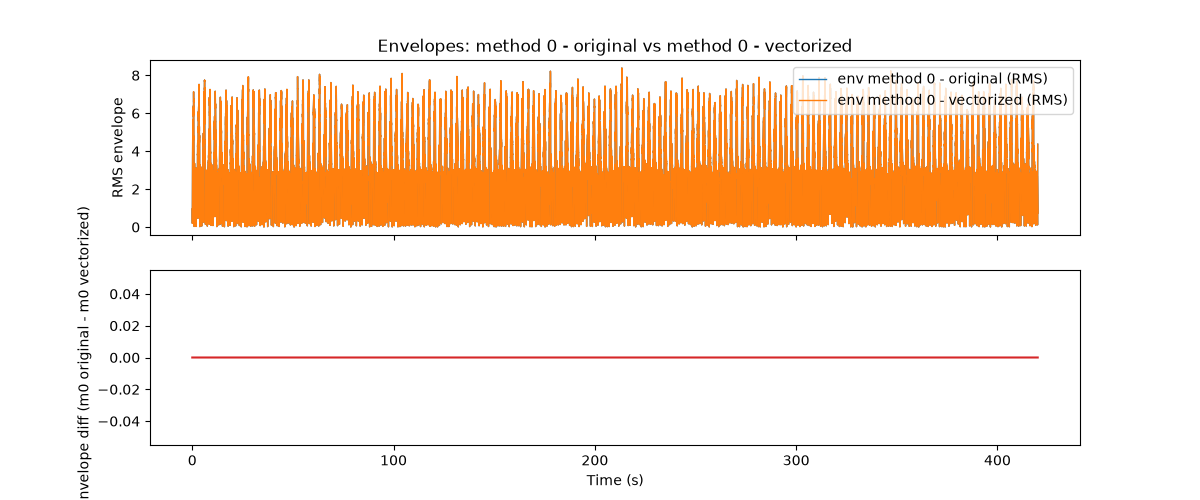

In [38]:
method = 0
n_reps = 100
test_methods(n_reps=n_reps, method=method)

Method 1 comparison
Original version (mean ± std): 0.006250 ± 0.000960 s
Vectorized version (mean ± std): 0.011321 ± 0.000846 s
Average speed improvement: -83.176% (mean over 100 reps)
Average time per peak (Original): 0.00001392 s/peak
Average time per peak (Vectorized):     0.00002521 s/peak
---------------------------------------------------------------------
Runs with exact zero max-difference: 100/100
Runs with max-difference ≈ 0 (tol=1e-12): 100/100
Max of max-differences across runs: 0.000000000000e+00
Mean of max-differences across runs: 0.000000000000e+00
Mean of mean-differences across runs: 0.000000000000e+00


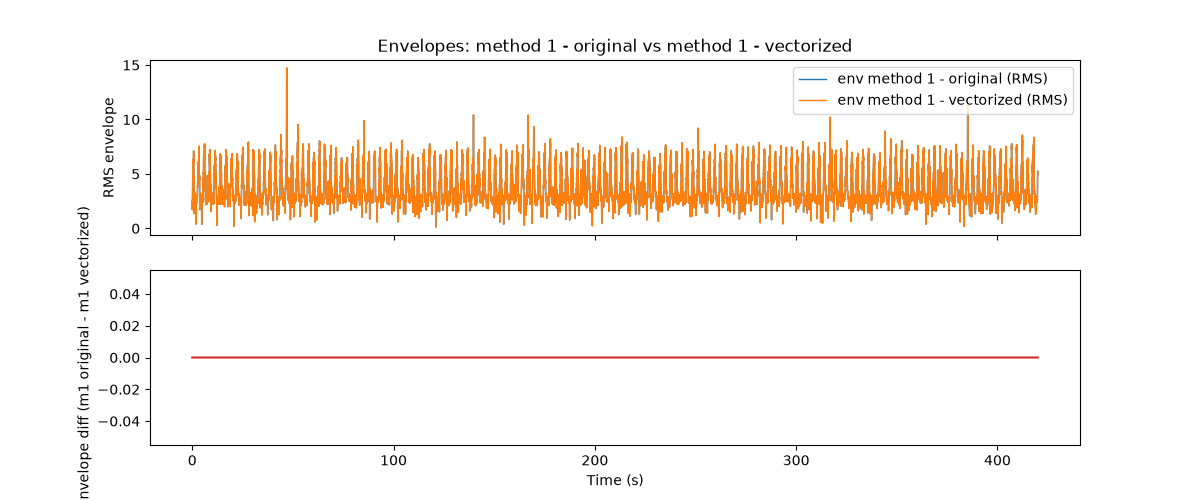

In [39]:
method = 1
n_reps = 100
test_methods(n_reps=n_reps, method=method)

Method 2 comparison
Original version (mean ± std): 0.015162 ± 0.002077 s
Vectorized version (mean ± std): 0.014049 ± 0.001293 s
Average speed improvement: 6.576% (mean over 100 reps)
Average time per peak (Original): 0.00003377 s/peak
Average time per peak (Vectorized):     0.00003129 s/peak
---------------------------------------------------------------------
Runs with exact zero max-difference: 100/100
Runs with max-difference ≈ 0 (tol=1e-12): 100/100
Max of max-differences across runs: 0.000000000000e+00
Mean of max-differences across runs: 0.000000000000e+00
Mean of mean-differences across runs: 0.000000000000e+00


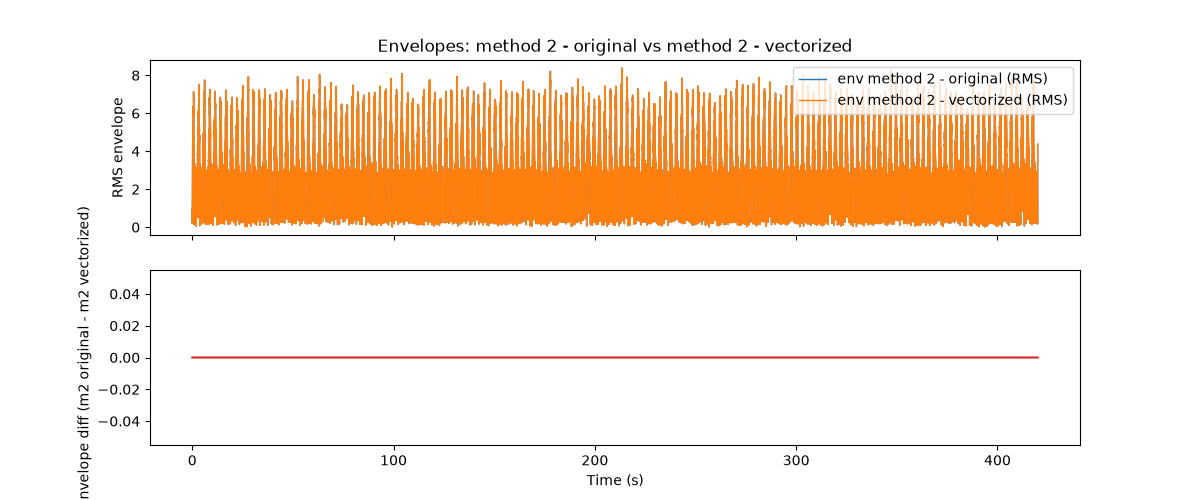

In [40]:
method = 2
n_reps = 100
test_methods(n_reps=n_reps, method=method)

Method 3 comparison
Original version (mean ± std): 0.061041 ± 0.008759 s
Vectorized version (mean ± std): 0.065966 ± 0.010684 s
Average speed improvement: -8.397% (mean over 100 reps)
Average time per peak (Original): 0.00013595 s/peak
Average time per peak (Vectorized):     0.00014692 s/peak
---------------------------------------------------------------------
Runs with exact zero max-difference: 100/100
Runs with max-difference ≈ 0 (tol=1e-12): 100/100
Max of max-differences across runs: 0.000000000000e+00
Mean of max-differences across runs: 0.000000000000e+00
Mean of mean-differences across runs: 0.000000000000e+00


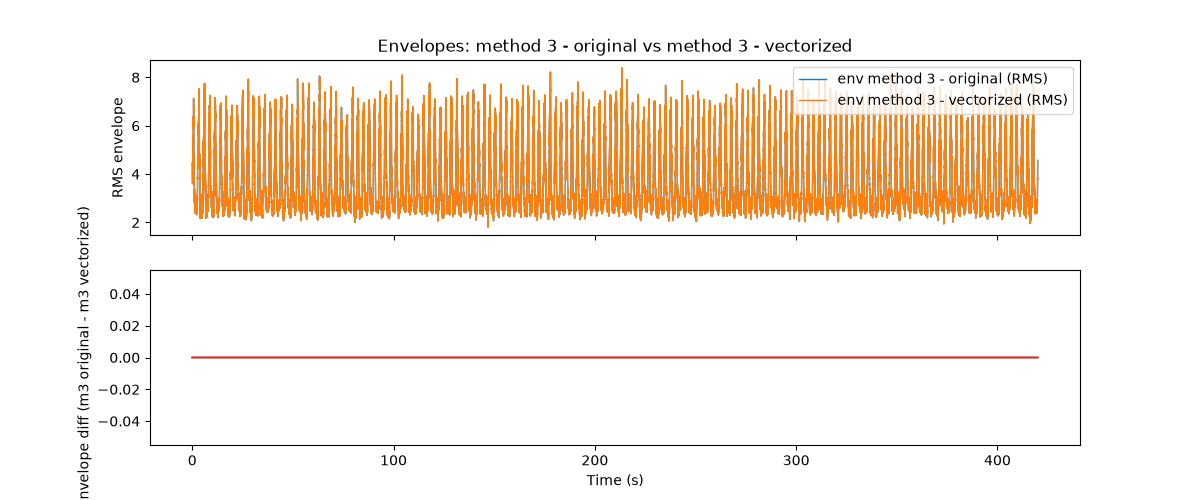

In [41]:
method = 3
n_reps = 100
test_methods(n_reps=n_reps, method=method)

Method 4 comparison


Original version (mean ± std): 0.091673 ± 0.010766 s
Vectorized version (mean ± std): 0.098956 ± 0.012667 s
Average speed improvement: -8.397% (mean over 100 reps)
Average time per peak (Original): 0.00020417 s/peak
Average time per peak (Vectorized):     0.00022039 s/peak
---------------------------------------------------------------------
Runs with exact zero max-difference: 0/100
Runs with max-difference ≈ 0 (tol=1e-12): 0/100
Max of max-differences across runs: 8.483163504991e-09
Mean of max-differences across runs: 8.483163504991e-09
Mean of mean-differences across runs: 3.679478330971e-11


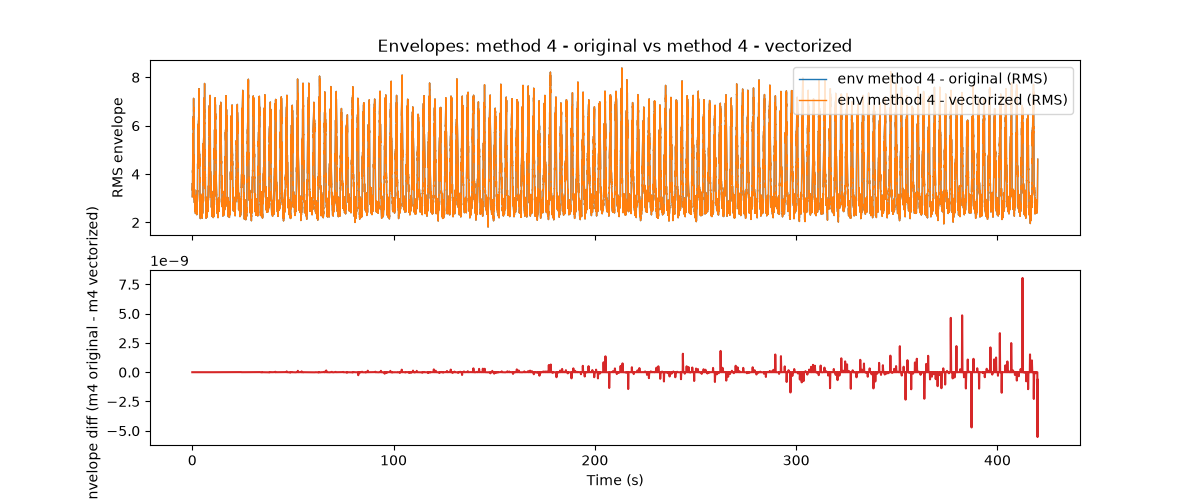

In [42]:
method = 4
n_reps = 100
test_methods(n_reps=n_reps, method=method)

Text(0.5, 0, 'Time (s)')

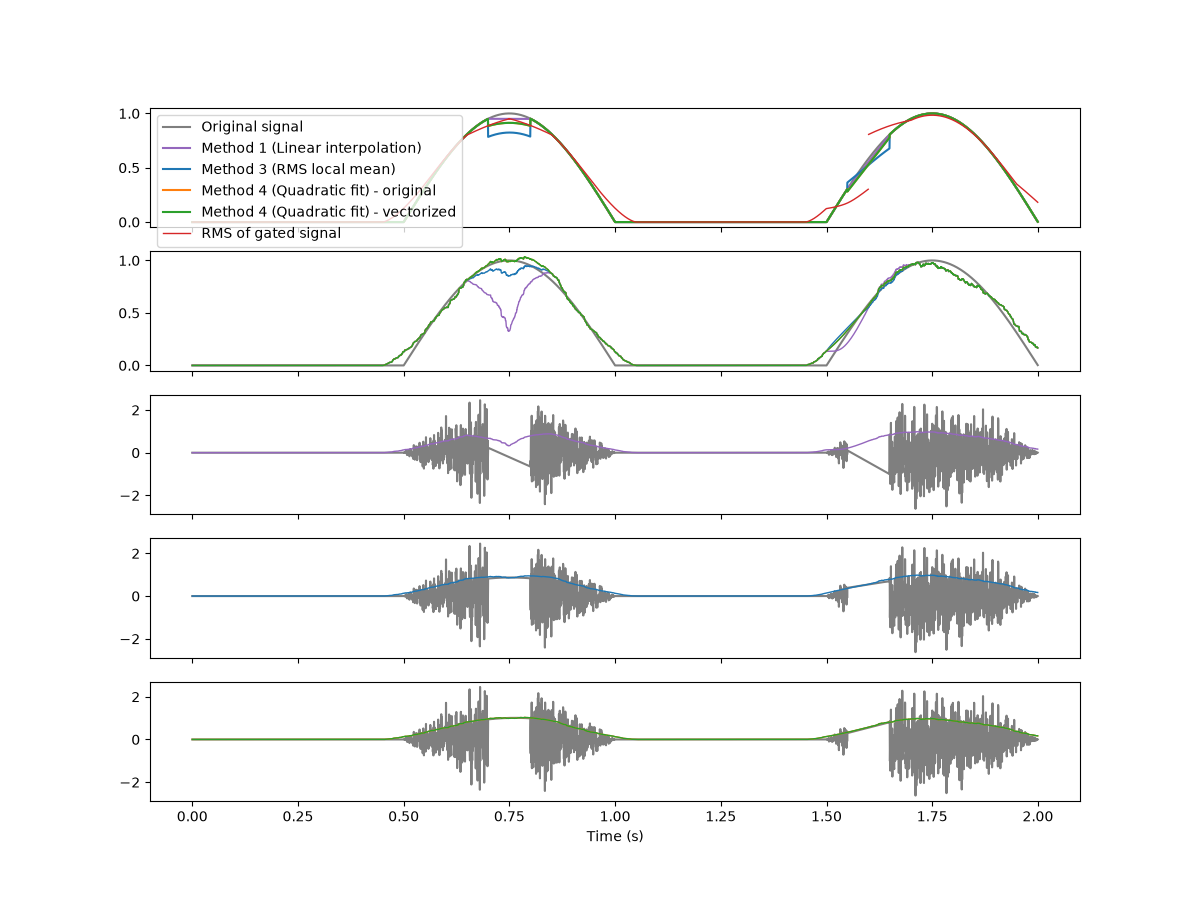

In [43]:
fs_test = 2048
t = np.arange(0, 2, 1/fs_test)
x = np.sin(2 * np.pi * (t + 0.5))
x[x < 0.0] = 0

peak_idxs = np.array([0.75 * fs_test, 1.6 * fs_test], dtype=int)
noise_fixed = np.random.RandomState(seed=1)
x_noise = x * noise_fixed.randn(*x.shape)

# Remaining envelope after gaiting (used for fills)
gate_width = 205
emg_x_gated = copy.deepcopy(x_noise)
max_sample = emg_x_gated.shape[0]

# With continuous data
peaks = np.asarray(peak_idxs, dtype=int).ravel()
if peaks.size > 0:
    # Build boolean mask of gate samples
    gate_mask = np.zeros(max_sample, dtype=bool)
    half_w = gate_width / 2
    starts = np.maximum(0, (peaks - half_w).astype(int))
    ends = np.minimum(max_sample, (peaks + half_w).astype(int))
    for s, e in zip(starts, ends):
        if s < e:
            gate_mask[s:e] = True

    # Compute RMS with gated samples as NaN
    emg_x_gated_base = x.copy()
    emg_x_gated_base[gate_mask] = np.nan
    emg_x_gated_rms = evl.full_rolling_rms(
        emg_x_gated_base, gate_width)
    emg_x_gated[gate_mask] = np.nan

x_lin = gating_vectorized(x, peak_idxs=peak_idxs, method=1, gate_width=205)
x_rms_lin = gating_vectorized(x, peak_idxs=peak_idxs, method=3, gate_width=205)
x_rms_quad_orig = gating_original(x, peak_idxs=peak_idxs, method=4, gate_width=205, poly_width=205)
x_rms_quad_vect = gating_vectorized(x, peak_idxs=peak_idxs, method=4, gate_width=205, poly_width=205)

# With stochastic data
gate_width = 205
emg_raw_gated = copy.deepcopy(x_noise)
max_sample = emg_raw_gated.shape[0]

peaks = np.asarray(peak_idxs, dtype=int).ravel()
if peaks.size > 0:
    # Build boolean mask of gate samples
    gate_mask = np.zeros(max_sample, dtype=bool)
    half_w = gate_width / 2
    starts = np.maximum(0, (peaks - half_w).astype(int))
    ends = np.minimum(max_sample, (peaks + half_w).astype(int))
    for s, e in zip(starts, ends):
        if s < e:
            gate_mask[s:e] = True

    # Compute RMS with gated samples as NaN
    emg_raw_gated_base = emg_raw_gated.copy()
    emg_raw_gated_base[gate_mask] = np.nan
    emg_raw_gated_rms = evl.full_rolling_rms(
        emg_raw_gated_base, gate_width)
    emg_raw_gated[gate_mask] = np.nan

x_lin_noise = x_lin * noise_fixed.randn(*x_lin.shape)
x_lin_gate_noise = gating_vectorized(x_noise, peak_idxs=peak_idxs, method=1, gate_width=205) 
x_lin_env = evl.full_rolling_rms(x_lin_gate_noise, 205)
x_rms_lin_noise = x_rms_lin * noise_fixed.randn(*x_rms_lin.shape)
x_rms_lin_gate_noise = gating_vectorized(x_noise, peak_idxs=peak_idxs, method=3, gate_width=205)
x_rms_lin_env = evl.full_rolling_rms(x_rms_lin_gate_noise, 205)
# x_rms_quad_noise = x_rms_quad_orig * noise_fixed.randn(*x_rms_quad_orig.shape)
x_rms_quad_gate_noise_orig = gating_original(x_noise, peak_idxs=peak_idxs, method=4, gate_width=205, poly_width=205)
x_rms_quad_env_orig = evl.full_rolling_rms(x_rms_quad_gate_noise_orig, 205)

x_rms_quad_gate_noise_vect = gating_vectorized(x_noise, peak_idxs=peak_idxs, method=4, gate_width=205, poly_width=205)
x_rms_quad_env_vect = evl.full_rolling_rms(x_rms_quad_gate_noise_vect, 205)

fig, ax = plt.subplots(5, 1, figsize=(12, 9), sharex=True)
ax[0].plot(t, x, label='Original signal', color='tab:gray')
ax[0].plot(t, x_lin, label='Method 1 (Linear interpolation)', color='tab:purple')  
ax[0].plot(t, x_rms_lin, label='Method 3 (RMS local mean)', color='tab:blue')
ax[0].plot(t, x_rms_quad_orig, label='Method 4 (Quadratic fit) - original', color='tab:orange')
ax[0].plot(t, x_rms_quad_vect, label='Method 4 (Quadratic fit) - vectorized', color='tab:green')

ax[0].plot(t, emg_x_gated_rms, label='RMS of gated signal', color='tab:red', lw=1)
ax[0].legend(loc='upper left')

ax[1].plot(t, x, label='Original signal', color='tab:gray')
ax[1].plot(t, x_lin_env, label='Method 1 (Linear interpolation) envelope', color='tab:purple', lw=1)
ax[1].plot(t, x_rms_lin_env, label='Method 3 (RMS local mean) envelope', color='tab:blue', lw=1)
ax[1].plot(t, x_rms_quad_env_orig, label='Method 4 (Quadratic fit) - original envelope', color='tab:orange', lw=1)
ax[1].plot(t, x_rms_quad_env_vect, label='Method 4 (Quadratic fit) - vectorized envelope', color='tab:green', lw=1)

ax[2].plot(t, x_lin_gate_noise, label='Method 1 (Linear interpolation) + noise', color='tab:gray')
ax[2].plot(t, x_lin_env, label='Method 1 (Linear interpolation) envelope', color='tab:purple', lw=1)

ax[3].plot(t, x_rms_lin_gate_noise, label='Method 3 (RMS local mean) + noise', color='tab:gray')
ax[3].plot(t, x_rms_lin_env, label='Method 3 (RMS local mean) envelope', color='tab:blue', lw=1)

ax[4].plot(t, x_rms_quad_gate_noise_orig, label='Method 4 (Quadratic fit) + noise', color='tab:gray')
ax[4].plot(t, x_rms_quad_env_orig, label='Method 4 (Quadratic fit) - original envelope', color='tab:orange', lw=1)
ax[4].plot(t, x_rms_quad_env_vect, label='Method 4 (Quadratic fit) - vectorized envelope', color='tab:green', lw=1)
ax[4].set_xlabel('Time (s)')